In [ ]:
from langgraph.graph import StateGraph, START, END
from langchain.chat_models import init_chat_model
from langchain_core.prompts import PromptTemplate
from typing import TypedDict, List, Dict, List
import json, traceback
from dotenv import load_dotenv
load_dotenv()
from logger import CustomLogger
logger = CustomLogger().get_logger(__name__)
import io
import contextlib
from langgraph.types import Command
from langgraph.checkpoint.memory import InMemorySaver
import pymupdf4llm
import base64
from langchain_core.messages import HumanMessage

from langgraph.checkpoint.memory import InMemorySaver
checkpointer = InMemorySaver()
from logger import CustomLogger
logger = CustomLogger().get_logger()

In [84]:
llm = init_chat_model(
    "gpt-5-mini-2025-08-07",
    temperature=0
)

In [85]:
class TestDataState(TypedDict):
    file_path: str
    image_path: str
    context: str
    kg_graph: str
    test_cases: List[Dict]
    test_data: List[Dict]

In [87]:

def encode_image_to_base64(image_path):
    """
    Encodes a local image file to a Base64 string.
    """
    with open(image_path, "rb") as image_file:
        encoded_bytes = base64.b64encode(image_file.read())
        # Decode the bytes to a UTF-8 string for use in JSON/text APIs
        encoded_string = encoded_bytes.decode('utf-8')
    return encoded_string

def convert_image_text_llm():
    # encode images
    image_path="docs/images/HMS.pdf-7-0.png"
    enoded_string  = encode_image_to_base64(image_path)
    image_url = f"data:image/jpeg;base64,{enoded_string}"
    prompt ="Convert blow image into text"
    
    # Construct the multimodal message
    msg = llm.invoke(
        [
            HumanMessage(
                content=[
                    {"type": "text", "text": prompt},
                    {"type": "image_url", "image_url": {"url": image_url}},
                ]
            )
        ]
    )
    return msg.content


## Prompts
KG_PROMPT=""" 
You are a Senior Software QA and Knowledge Graph expert.

Your task is to analyze the given software specification or requirement document 
and convert it into a structured Knowledge Graph (KG) that can later be used 
to automatically generate test plans and test data.

Focus on extracting entities, attributes, relationships, business rules, 
and validation logic relevant for software testing.

--------------------------------------------------
INPUT
--------------------------------------------------
Software Specification / Requirement Document:

{context}

--------------------------------------------------
TASKS
--------------------------------------------------

1. Identify all important entities in the specification such as:
   - System components
   - Modules
   - Features
   - User roles
   - APIs
   - Inputs and outputs
   - Data objects
   - Validation rules
   - Business rules
   - Constraints
   - External systems

2. Extract attributes for each entity:
   Example:
   - field name
   - datatype
   - allowed values
   - required/optional
   - validation rules
   - default values

3. Identify relationships between entities such as:
   - "user SUBMITS order"
   - "order CONTAINS items"
   - "payment VALIDATES card"
   - "API RETURNS response"

4. Extract test-relevant rules including:
   - validation rules
   - boundary conditions
   - conditional logic
   - dependency between fields
   - error scenarios

5. Represent the result as a Knowledge Graph with:

Nodes:
- id
- type
- description
- attributes

Edges:
- source
- relation
- target
- description

6. Also identify potential test scenarios linked to nodes.
7. Output format should be in Json.
--------------------------------------------------
IMPORTANT RULES
--------------------------------------------------

- Extract both explicit and implicit relationships.
- Include validation rules as nodes if necessary.
- Capture business logic dependencies.
- Normalize entity names.
- Avoid duplicate nodes.
- Ensure relationships are meaningful for test generation.

The Knowledge Graph should be optimized for downstream tasks:
- automatic test case generation
- synthetic test data generation
"""




PROMPT_TEST_CASE ="""
You are a Senior Software QA expert. Your task is to analyze the software requirements and Knowledge graph. Create a comprehensive test cases which should cover all features of the application.
SOFTWARE REQUIREMENTS:
{context}

KNOWLEDGE GRAPH:
{kg}

IMPORTANT RULES
- Test cases should cover possible scenarios. 
- Avoid Dulicate test cases
- Test cases should be complete.
- Stick to provide context , and do not invent facts. 
- Outpu should be in json format
"""

PROMPT_TEST_DATA ="""
You are a Senior Software QA expert and test data facilitator. You task is to analyze below context, Knowledge graph and test cases to create test data.
CONTEXT:
{context}

KNOWLEDGE GRAPH:
{kg}

TEST CASES: 
{test_cases}


IMPORTANT RULES
- Test data should be complete.
- Stick to provide context , and do not invent facts. 
- Output should be in json format
 
"""

##### Load docs

In [88]:
def build_context(state: TestDataState):
    path = state["file_path"]
    md_text = pymupdf4llm.to_markdown(path)
    md_text_images = pymupdf4llm.to_markdown(
    doc=path,
    page_chunks=True,
    write_images=True,
    image_path="docs/images",
    image_format="png",
    dpi=300
    )
    image_to_text = convert_image_text_llm()

    return {"context": md_text + image_to_text}

In [89]:
def create_kg_from_context(state: TestDataState):
    context = state["context"]
    prompt_template  = PromptTemplate.from_template(template=KG_PROMPT)
    prompt= prompt_template.format(context=context)
    response = llm.invoke(prompt)
    return {"kg_graph": response.content}

In [90]:
def generate_test_cases(state: TestDataState):
    context = state['context']
    kg = state["kg_graph"]
    prompt_template  = PromptTemplate.from_template(template=PROMPT_TEST_CASE)
    prompt = prompt_template.format(context=context,kg=kg)
    response =llm.invoke(prompt)
    return {"test_cases": response.content}


In [91]:
def generate_test_data(state: TestDataState):
    context = state['context']
    kg = state["kg_graph"]
    test_cases = json.dumps(state["test_cases"])
    prompt_template  = PromptTemplate.from_template(template=PROMPT_TEST_DATA)
    prompt= prompt_template.format(context=context,kg=kg,test_cases=test_cases)
    response =llm.invoke(prompt)

    return {"test_data": response.content}

In [92]:
def llm_generate(state: TestDataState):
    res = llm.invoke(state["prompt"])
    return {"llm_output": res.content}

##### Create Graph

In [93]:
TestDataGraph = StateGraph(TestDataState)
TestDataGraph.add_node("build_context",build_context)
TestDataGraph.add_node("create_kg", create_kg_from_context)
TestDataGraph.add_node("gen_test_cases",generate_test_cases)
TestDataGraph.add_node("gen_test_data", generate_test_data)

TestDataGraph.add_edge(START,"build_context")
TestDataGraph.add_edge("build_context","create_kg")
TestDataGraph.add_edge("create_kg","gen_test_cases")
TestDataGraph.add_edge("gen_test_cases","gen_test_data")
TestDataGraph.add_edge("gen_test_data",END)
TestDataGraph=TestDataGraph.compile()

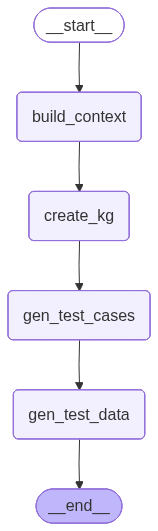

In [101]:
from IPython.display import Image, display
# Displays the graph as an image in Jupyter Notebook
display(Image(TestDataGraph.get_graph().draw_mermaid_png())) 

In [94]:
initial_state = { 
    "file_path": "docs/HMS.pdf",
    "image_path": "docs/images/"
}

In [95]:
response = TestDataGraph.invoke(initial_state)

HTTP Request: POST https://api.openai.com/v1/chat/completions "HTTP/1.1 200 OK"
HTTP Request: POST https://api.openai.com/v1/chat/completions "HTTP/1.1 200 OK"
HTTP Request: POST https://api.openai.com/v1/chat/completions "HTTP/1.1 200 OK"
HTTP Request: POST https://api.openai.com/v1/chat/completions "HTTP/1.1 200 OK"


In [100]:
json.loads(response["test_data"])["test_data_sets"][0]

{'test_case_id': 'TC001',
 'description': 'Login - valid credentials (Owner/Manager/Employee)',
 'seed_data': {'users': [{'user_id': 'owner-1',
    'role': 'Owner',
    'username': 'owner.jane',
    'plaintext_password': 'OwnerPass!23',
    'stored_password_hash': 'hash(OwnerPass!23)'},
   {'user_id': 'manager-1',
    'role': 'Manager',
    'username': 'manager.sara',
    'plaintext_password': 'ManagerPass!23',
    'stored_password_hash': 'hash(ManagerPass!23)'},
   {'user_id': 'employee-1',
    'role': 'Employee',
    'username': 'employee.mike',
    'plaintext_password': 'EmployeePass!23',
    'stored_password_hash': 'hash(EmployeePass!23)'}]},
 'input': {'username': 'owner.jane', 'password': 'OwnerPass!23'}}

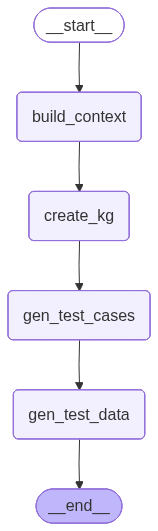